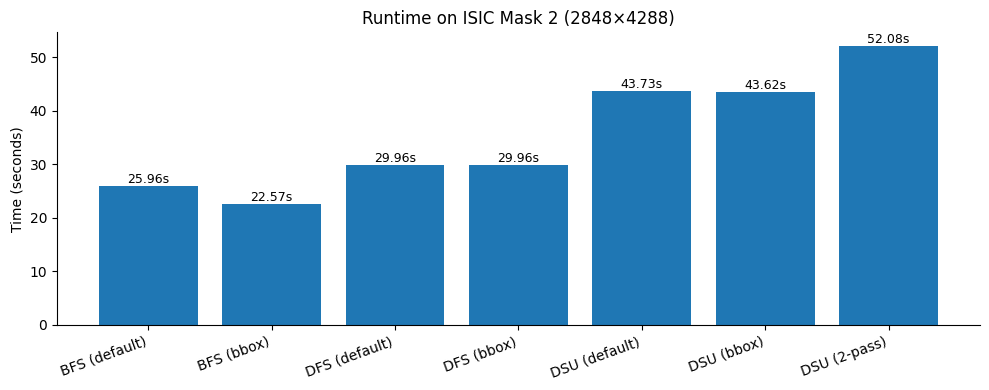

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==== 原始数据（来自你的实验） ====
# default
t_bfs_default = 25.9642 
t_dfs_default = 29.9586
t_dsu_default = 43.7289

'''
=== Performance Summary ===
BFS: time=25.9642s, peak_mem=58.35 MB
DFS: time=29.9586s, peak_mem=95.98 MB
DSU: time=43.7289s, peak_mem=559.02 MB

'''

# crop_to_bbox
t_bfs_bbox = 22.5666
t_dfs_bbox = 29.9611
t_dsu_bbox = 43.6153

'''
=== bbox Performance Summary ===
BFS: time=22.5666s, peak_mem=58.31 MB
DFS: time=29.9611s, peak_mem=95.98 MB
DSU: time=43.6153s, peak_mem=559.02 MB

'''

# DSU two-pass
t_dsu_2pass = 52.0836

'''
DSU: time=52.0836s, peak_mem=123.53 MB

Image: 2848x4288  | Foreground pixels: 2134643  (17.48%)
BBox area: 12212224  (100.00%)
'''

# 为了让图更清晰，采用“方法+配置”的扁平分类（一个图里画完）
labels = [
    "BFS (default)", "BFS (bbox)",
    "DFS (default)", "DFS (bbox)",
    "DSU (default)", "DSU (bbox)", "DSU (2-pass)"
]
runtimes = [
    t_bfs_default, t_bfs_bbox,
    t_dfs_default, t_dfs_bbox,
    t_dsu_default, t_dsu_bbox, t_dsu_2pass
]

x = np.arange(len(labels))

plt.figure(figsize=(10,4))
bars = plt.bar(x, runtimes)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel("Time (seconds)")
plt.title("Runtime on ISIC Mask 2 (2848×4288)")

# 在柱子上方标注数值
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}s",
             ha='center', va='bottom', fontsize=9)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


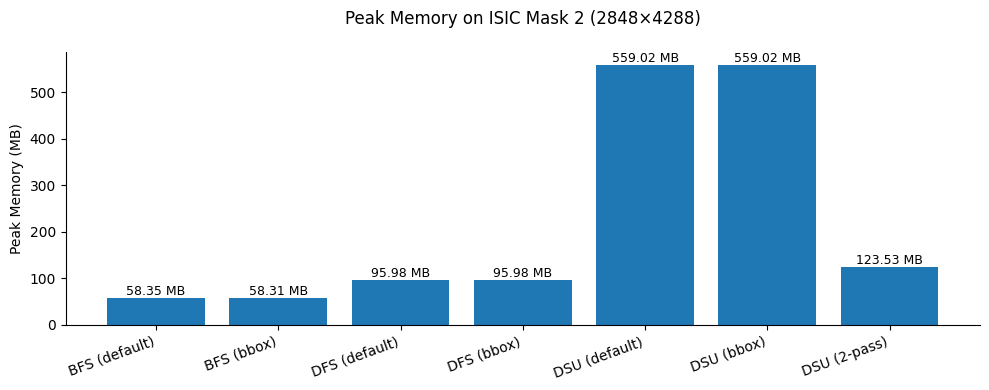

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Original（MB） ====
m_bfs_default = 58.35 
m_dfs_default = 95.98
m_dsu_default = 559.02

m_bfs_bbox = 58.31
m_dfs_bbox = 95.98
m_dsu_bbox = 559.02

m_dsu_2pass = 123.53

labels = [
    "BFS (default)", "BFS (bbox)",
    "DFS (default)", "DFS (bbox)",
    "DSU (default)", "DSU (bbox)", "DSU (2-pass)"
]
memories = [
    m_bfs_default, m_bfs_bbox,
    m_dfs_default, m_dfs_bbox,
    m_dsu_default, m_dsu_bbox, m_dsu_2pass
]

x = np.arange(len(labels))

plt.figure(figsize=(10,4))
bars = plt.bar(x, memories)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel("Peak Memory (MB)")
plt.title("Peak Memory on ISIC Mask 2 (2848×4288)", pad=20)

# 数值标注
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f} MB",
             ha='center', va='bottom', fontsize=9)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


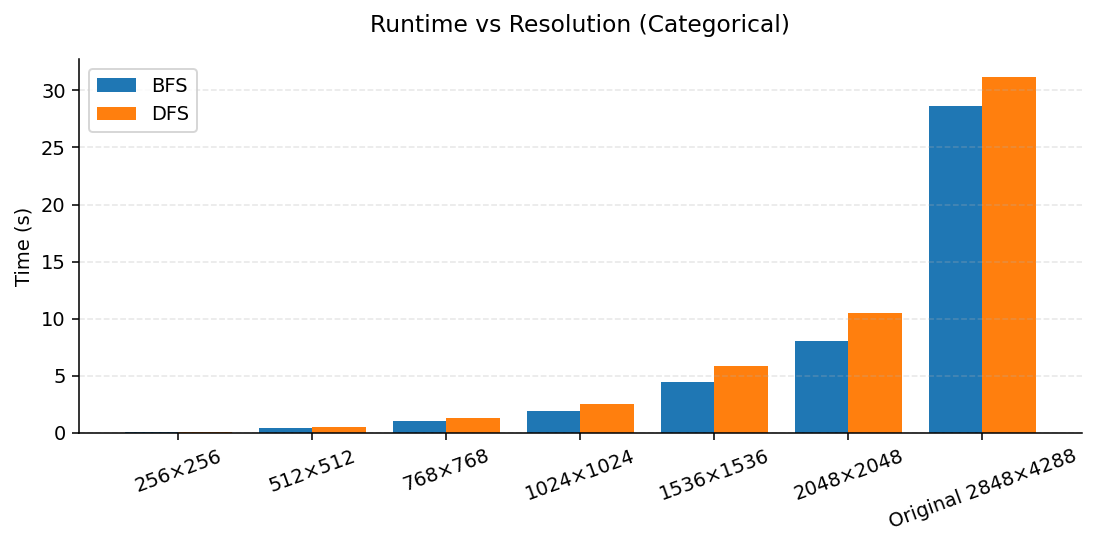

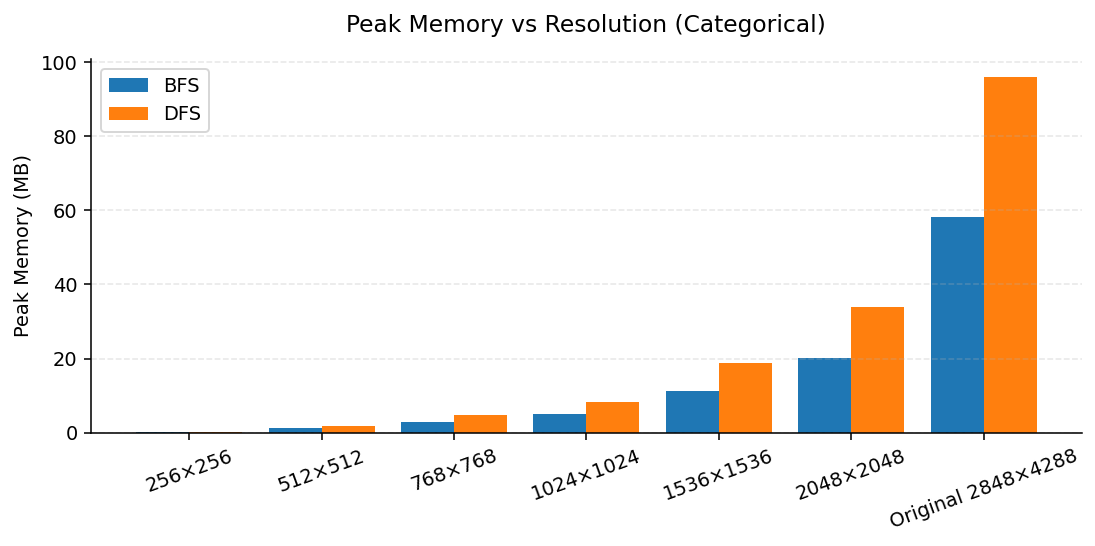

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1) 按你想要的“类别顺序”给出标签（包含 Original）
labels = ["256×256", "512×512", "768×768", "1024×1024", "1536×1536", "2048×2048", "Original 2848×4288"]

# 2) Fill in the actual measurement data in the same order (if there is no data, use None or np.nan first)
t_bfs = [0.0694, 0.3989, 1.0487, 1.9096, 4.4509, 8.0529, 28.6694]   
t_dfs = [0.0623, 0.4983, 1.3329, 2.5004, 5.8123, 10.5126, 31.1732]   
# t_dsu = [0.1490, 0.68017, 1.9555, 3.6029, 8.4116, 15.1877, 45.4750]   

m_bfs = [0.32, 1.26, 2.83,  5.03,  11.29, 20.06, 58.32]    # MB
m_dfs = [0.33, 1.96,  4.92, 8.41,  18.69, 33.87, 95.97]
# m_dsu = [3.09, 12.20,  27.42, 48.73, 109.62, 194.86, 567.34]

# 3) A small gadget for drawing group bar charts (automatically skip NaN)
def grouped_bars(ax, labels, series, series_names, ylabel, title):
    x = np.arange(len(labels))
    k = len(series)
    width = 0.8 / k

    for i, y in enumerate(series):
        # Change NaN to 0 but do not display the numerical label
        y_plot = [0 if (v is None or (isinstance(v, float) and np.isnan(v))) else v for v in y]
        ax.bar(x + (i - (k-1)/2)*width, y_plot, width=width, label=series_names[i])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=14)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    # Remove the upper right border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4) 生成两张图
fig1, ax1 = plt.subplots(figsize=(8,4), dpi=140)
grouped_bars(
    ax1, labels,
    series=[t_bfs, t_dfs],
    series_names=["BFS", "DFS"],
    ylabel="Time (s)",
    title="Runtime vs Resolution (Categorical)"
)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8,4), dpi=140)
grouped_bars(
    ax2, labels,
    series=[m_bfs, m_dfs],
    series_names=["BFS", "DFS"],
    ylabel="Peak Memory (MB)",
    title="Peak Memory vs Resolution (Categorical)"
)
plt.tight_layout()
plt.show()
